<a href="https://colab.research.google.com/github/Yashas7206988696/Supervised-learning-on-Jee-mains-marks-from-year-2013-to-2025/blob/main/Supervisedlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (24248, 13)
Dataset head:
    Year   Exam_Date                Name  ...   Rank Percentile Rank_Category
0  2013  2013-04-21    Tristan Bhandari  ...   78.0  51.572327             1
1  2013  2013-04-18  Rehaan Rajagopalan  ...   66.0  59.119497             1
2  2013  2013-04-19     Yatin Natarajan  ...   50.0  69.182390             0
3  2013  2013-04-21        Peter Bhalla  ...   85.0  39.130435             2
4  2013  2013-04-17       Jairaj Mannan  ...  114.0  28.930818             2

[5 rows x 13 columns]

Descriptive statistics:
                Year   Maths_Marks  ...    Percentile  Rank_Category
count  24248.000000  24247.000000  ...  24247.000000   24248.000000
mean    2018.566480     70.088712  ...     50.589560       1.267527
std        3.496139     17.577824  ...     20.873703       0.784683
min     2013.000000     40.000000  ...      0.591716       0.000000
25%     2016.000000     55.000000  ...     35.582822       1.000000
50%     2019.000000     70.000000  ... 

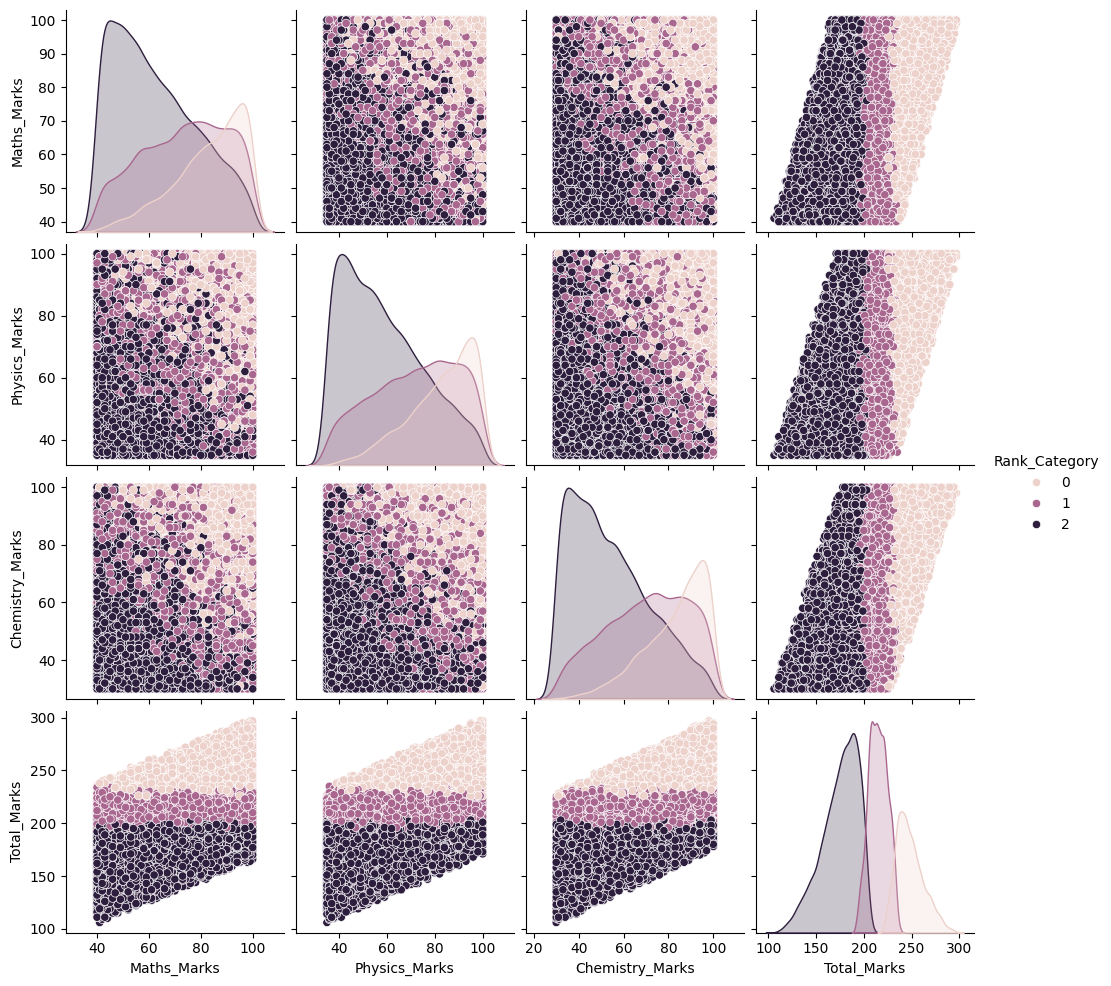

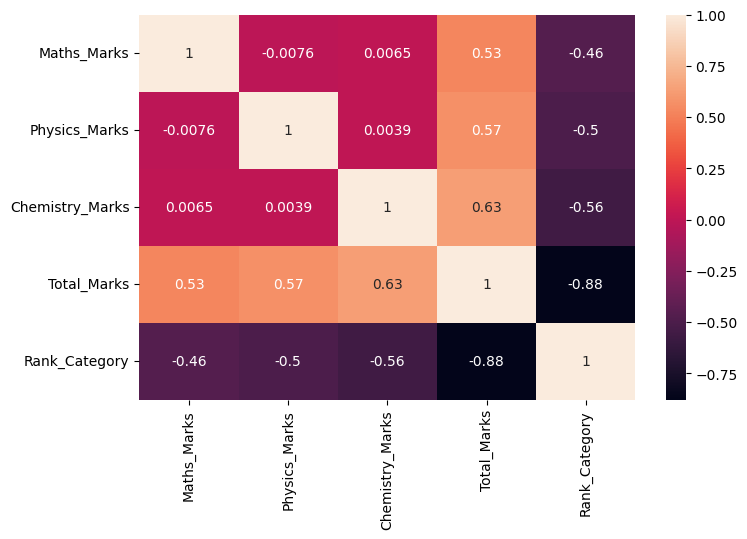

Model: RandomForestClassifier
Accuracy: 0.9086
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.90      1242
           1       0.85      0.85      0.85      1842
           2       0.94      0.95      0.95      2978

    accuracy                           0.91      6062
   macro avg       0.90      0.90      0.90      6062
weighted avg       0.91      0.91      0.91      6062

--------------------------------------------------
Model: DecisionTreeClassifier
Accuracy: 0.8862
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89      1242
           1       0.81      0.82      0.81      1842
           2       0.94      0.92      0.93      2978

    accuracy                           0.89      6062
   macro avg       0.88      0.88      0.88      6062
weighted avg       0.89      0.89      0.89      6062

---------------------------------------------

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv('jeemains.csv')

# Convert Rank into categorical classes for classification (example: 3 classes)
def rank_category(rank):
    if rank <= 50:
        return 0
    elif rank <= 80:
        return 1
    else:
        return 2


mains.head()


df['Rank_Category'] = df['Rank'].apply(rank_category)

# EDA
print("Dataset shape:", df.shape)
print("Dataset head:\n", df.head())
print("\nDescriptive statistics:\n", df.describe())
print("\nDataset info:\n")
df.info()

# Visualization (uncomment to view plots)
sns.pairplot(df, hue='Rank_Category', vars=['Maths_Marks', 'Physics_Marks', 'Chemistry_Marks', 'Total_Marks'])
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df[['Maths_Marks', 'Physics_Marks', 'Chemistry_Marks', 'Total_Marks', 'Rank_Category']].corr(), annot=True)
plt.show()

# Features and target
features = ['Maths_Marks', 'Physics_Marks', 'Chemistry_Marks', 'Total_Marks']
X = df[features]
y = df['Rank_Category']

# Impute missing values in features using mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Update features with imputed data
X = pd.DataFrame(X_imputed, columns=features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Helper function to train and evaluate classification models
def train_evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Model: {model.__class__.__name__}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*50)
    return acc

# Random Forest
rf = RandomForestClassifier(random_state=42)
train_evaluate_model(rf)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
train_evaluate_model(dt)

# Logistic Regression
lr = LogisticRegression(max_iter=200)
train_evaluate_model(lr)

# AdaBoost
ada = AdaBoostClassifier(random_state=42)
train_evaluate_model(ada)

# Linear Regression (for reference, regression on categorical labels)
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
y_pred_reg = lr_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred_reg)
print(f"Linear Regression Mean Squared Error: {mse:.4f}")

# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50,20,10,78,91,190,183,1,19,100],
    'max_depth': [None, 10,50,20,10,78,91,190,183,1,19,100,20],
    'min_samples_split': [2,50,20,10,78,91,190,183,1,19,1,5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Random Forest Best Parameters:", grid_search.best_params_)
print("Best Random Forest Model Performance:")
train_evaluate_model(best_rf)